# Modelo Predictivo de Accidentes Automovilísticos
## Universidad Tecnológica de Panamá — Maestría en Analítica de Datos
### Proyecto Integrador II — 2026

## Nota sobre el dataset
El dataset US Accidents fue filtrado para el estado de **Florida**,
seleccionado por su similitud climática y estructural con Panamá
(clima subtropical, infraestructura mixta urbana/rural, geografía costera).
La granularidad geográfica se trabaja a nivel de **County** y **City**.

**Enfoque del modelo — Dos etapas:**
- **Etapa 1:** Estimar la *probabilidad de ocurrencia* de un accidente por zona geográfica
- **Etapa 2:** Dado que ocurre un accidente, predecir su *nivel de severidad* (Low / Moderate / High)

---
## 1. Setup & Carga de Datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# format all floating-point numbers to 2 decimal places when displaying them in tables
pd.set_option('display.float_format', lambda x: '%.2f' % x)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_file = '/content/drive/MyDrive/UTP/2024/s107_Proyector_Integrador_1/final_project/notebooks/data/US_Accidents_FL.csv'

traffic_accidents_raw = pd.read_csv(csv_file) # leemos el dataset


---
## 2. Exploración Inicial (EDA)

In [ ]:
# Columnas disponibles
traffic_accidents_raw.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [ ]:
print(f"Total columnas: {len(traffic_accidents_raw.columns)}")
print(f"Total registros: {len(traffic_accidents_raw):,}")

Total columnas: 46
Total registros: 880,192


In [ ]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

numeric_df = traffic_accidents_raw.select_dtypes(include=numerics)
len(numeric_df.columns)

13

In [ ]:
traffic_accidents_raw.head(3)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-116062,Source2,3,2016-11-30 15:36:03,2016-11-30 17:09:22,27.98,-82.33,NaN,NaN,0.01,Queueing traffic and two left lane blocked due to accident on I-75 Southbound after Exits 260 260A 260B FL-574 Dr Martin Luther King Jr Blvd.,E Dr Martin Luther King Jr Blvd,Tampa,Hillsborough,FL,33610,US,US/Eastern,KVDF,2016-11-30 15:35:00,80.60,NaN,70.00,29.94,10.00,SSW,5.80,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1,A-116063,Source2,3,2016-11-30 16:25:35,2016-11-30 17:12:25,27.98,-82.33,NaN,NaN,0.01,Queueing traffic and 2 left lane closed due to accident on I-75 Southbound at Exits 260 260A 260B FL-574 Dr Martin Luther King Jr Blvd.,E Dr Martin Luther King Jr Blvd,Tampa,Hillsborough,FL,33610,US,US/Eastern,KVDF,2016-11-30 16:35:00,80.60,NaN,65.00,29.94,10.00,WSW,6.90,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
2,A-116064,Source2,2,2016-11-30 16:40:31,2016-11-30 17:10:19,25.63,-80.37,NaN,NaN,0.01,Accident on FL-992 152nd St at Lincoln Blvd.,SW 152nd St,Miami,Miami-Dade,FL,33157-1147,US,US/Eastern,KTMB,2016-11-30 16:53:00,80.10,NaN,71.00,29.96,10.00,SE,9.20,NaN,Mostly Cloudy,False,False,True,False,False,False,False,False,False,True,False,True,False,Day,Day,Day,Day


In [ ]:
traffic_accidents_raw.shape

(880192, 46)

In [ ]:
traffic_accidents_raw.dtypes

,0
ID,object
Source,object
Severity,int64
Start_Time,object
End_Time,object
Start_Lat,float64
Start_Lng,float64
End_Lat,float64
End_Lng,float64
Distance(mi),float64


---
## 3. Limpieza de Datos

### 3.1 Identificar valores nulos

In [ ]:
# Identificar valores nulos
missing_values = traffic_accidents_raw.isnull().sum()
missing_values[missing_values > 0]

,0
End_Lat,282640
End_Lng,282640
Street,1251
City,33
Zipcode,765
Timezone,766
Airport_Code,1007
Weather_Timestamp,5458
Temperature(F),13828
Wind_Chill(F),189358


In [ ]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
numeric_df = traffic_accidents_raw.select_dtypes(include=numerics)

# Variables necesarias para limpieza y correlación
number_columns     = traffic_accidents_raw.select_dtypes(include=np.number).columns.to_list()
categorical_columns = traffic_accidents_raw.select_dtypes(include='object').columns.to_list()

print(f"Columnas numéricas:    {len(number_columns)}")
print(f"Columnas categóricas:  {len(categorical_columns)}")

Columnas numéricas:    13
Columnas categóricas:  20


In [ ]:
# Tratamiento de valores nulos
# Numéricas → mediana | Categóricas → moda
for col in number_columns:
    traffic_accidents_raw[col] = traffic_accidents_raw[col].fillna(
        traffic_accidents_raw[col].median()
    )

for col in categorical_columns:
    traffic_accidents_raw[col] = traffic_accidents_raw[col].fillna(
        traffic_accidents_raw[col].mode()[0]
    )

print(f"Nulos restantes: {traffic_accidents_raw.isnull().sum().sum()}")

Nulos restantes: 0


In [ ]:
traffic_accidents_raw.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00
mean,2.14,27.53,-81.48,27.41,-81.38,0.53,75.40,75.63,71.37,30.02,9.52,8.46,0.01
std,0.41,1.56,1.44,1.29,1.20,1.67,10.38,9.62,17.12,0.16,1.68,5.04,0.06
min,1.00,24.55,-87.56,24.57,-87.62,0.00,-58.00,-80.00,1.00,0.00,0.00,0.00,0.00
25%,2.00,25.93,-82.25,26.07,-81.50,0.00,70.00,73.00,59.00,29.94,10.00,5.00,0.00
50%,2.00,27.76,-81.40,27.41,-81.33,0.10,77.00,77.00,72.00,30.02,10.00,8.00,0.00
75%,2.00,28.53,-80.32,28.19,-80.38,0.38,82.00,81.00,86.00,30.09,10.00,12.00,0.00
max,4.00,31.00,-80.04,31.01,-80.04,148.36,174.00,174.00,100.00,58.63,72.00,984.00,9.98


### 3.2 Valores únicos por columna

In [ ]:
# Valores únicos por columna
unique_values_df = pd.DataFrame({
    'Columna': traffic_accidents_raw.columns,
    'Valores Únicos': [traffic_accidents_raw[col].nunique() for col in traffic_accidents_raw.columns]
})
display(unique_values_df)

,Columna,Valores Únicos
0,ID,880192
1,Source,3
2,Severity,4
3,Start_Time,662141
4,End_Time,759762
5,Start_Lat,264142
6,Start_Lng,249042
7,End_Lat,171907
8,End_Lng,169816
9,Distance(mi),10630


### 3.3 Verificar duplicados

In [ ]:
# Verificar duplicados
print(f"Filas duplicadas: {traffic_accidents_raw.duplicated().sum()}")

Filas duplicadas: 0


In [ ]:
traffic_accidents_raw.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00
mean,2.14,27.53,-81.48,27.41,-81.38,0.53,75.40,75.63,71.37,30.02,9.52,8.46,0.01
std,0.41,1.56,1.44,1.29,1.20,1.67,10.38,9.62,17.12,0.16,1.68,5.04,0.06
min,1.00,24.55,-87.56,24.57,-87.62,0.00,-58.00,-80.00,1.00,0.00,0.00,0.00,0.00
25%,2.00,25.93,-82.25,26.07,-81.50,0.00,70.00,73.00,59.00,29.94,10.00,5.00,0.00
50%,2.00,27.76,-81.40,27.41,-81.33,0.10,77.00,77.00,72.00,30.02,10.00,8.00,0.00
75%,2.00,28.53,-80.32,28.19,-80.38,0.38,82.00,81.00,86.00,30.09,10.00,12.00,0.00
max,4.00,31.00,-80.04,31.01,-80.04,148.36,174.00,174.00,100.00,58.63,72.00,984.00,9.98


### 3.4 Boxplots para detección de outliers

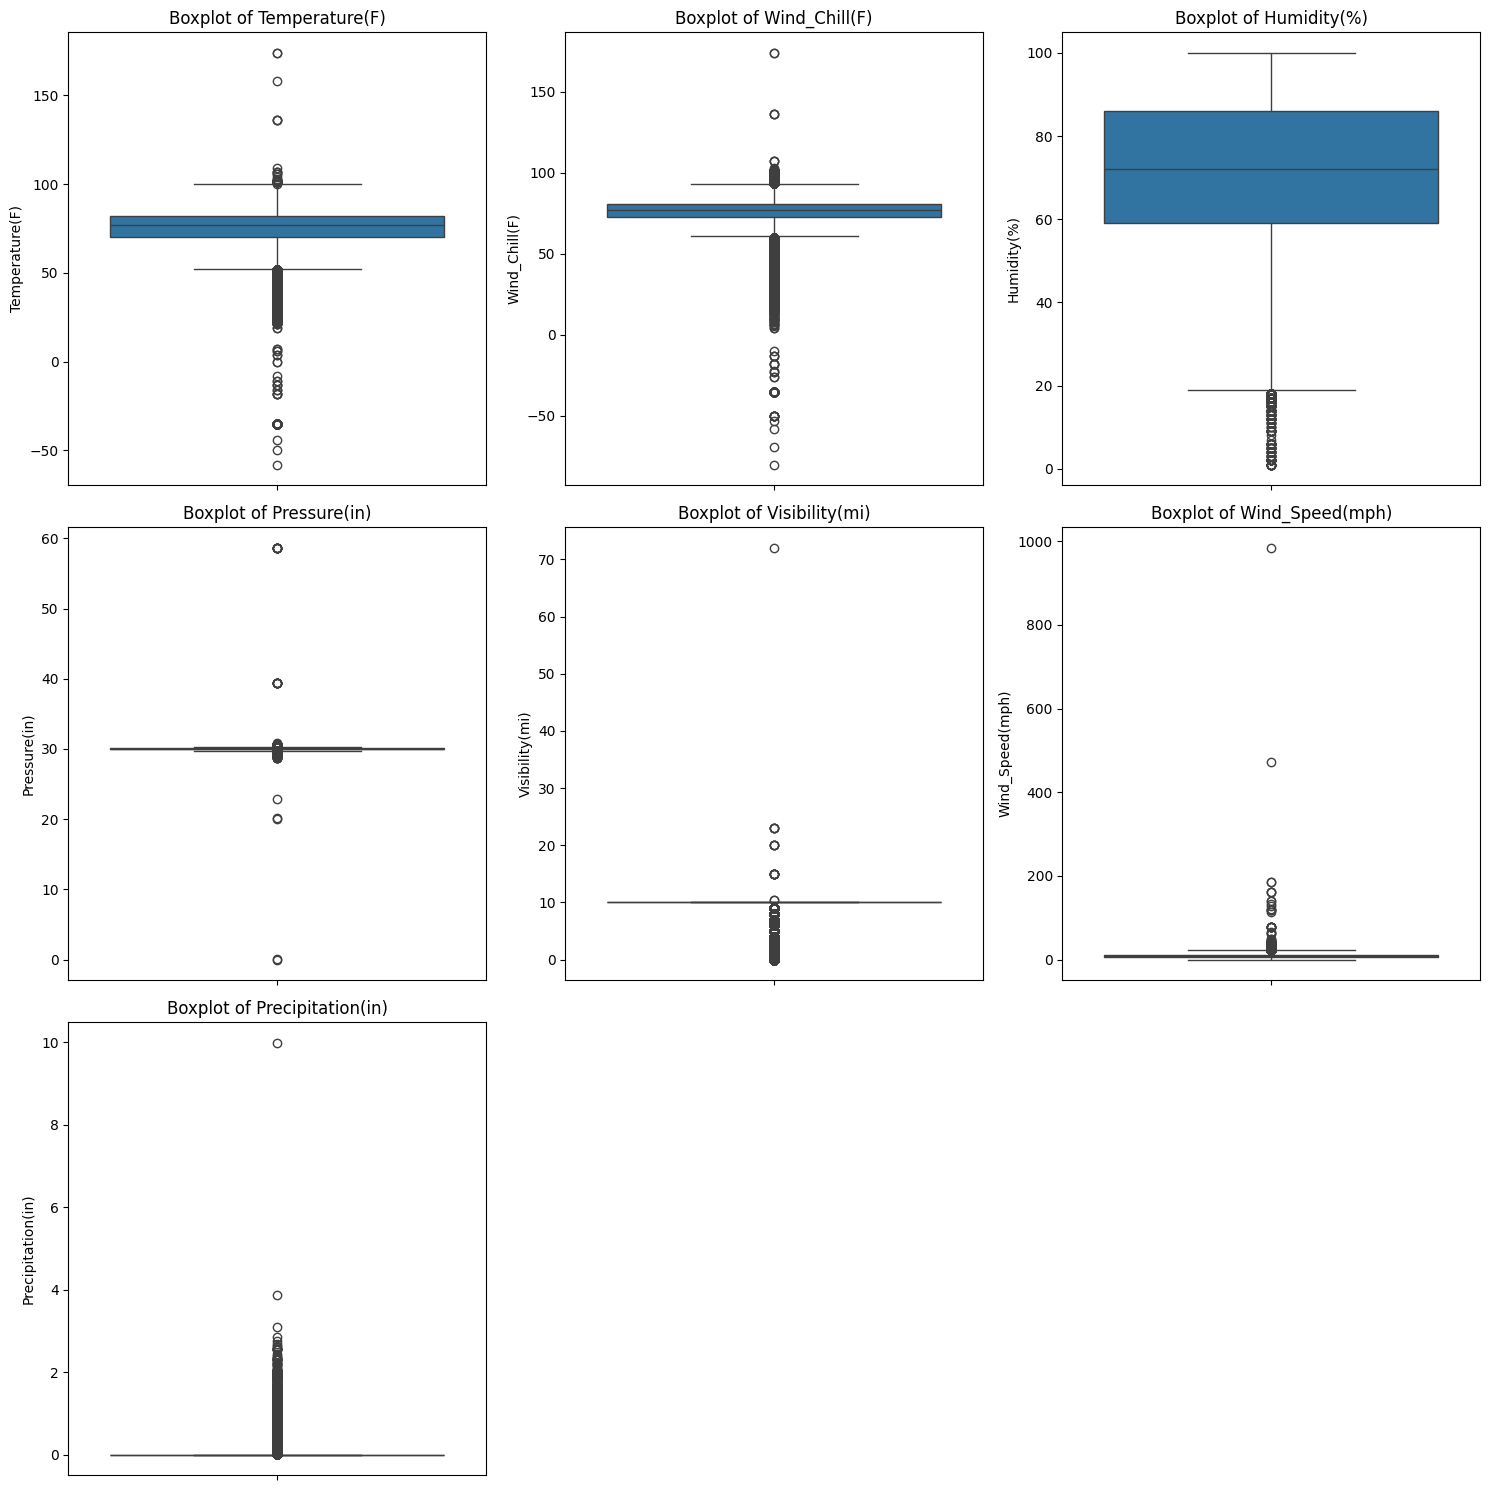

Variables analizadas: 7
Variables excluidas:  ['Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Severity', 'Duration_min', 'Distance(mi)', 'lat_round', 'lng_round']


In [ ]:
# Boxplots para detección de outliers

# Se excluyen variables que no aportan al análisis de distribución:
# - End_Lat, End_Lng: coordenadas de fin, redundantes con Start_Lat/Lng
# - Severity: es la variable objetivo, no una feature
# - Duration_min: analizada por separado con detalle en sección anterior
cols_excluir = ['Start_Lat','Start_Lng','End_Lat', 'End_Lng', 'Severity', 'Duration_min','Distance(mi)','lat_round','lng_round']

cols_boxplot = [
    col for col in traffic_accidents_raw.select_dtypes(
        include=['float64', 'int64']
    ).columns
    if col not in cols_excluir
]

num_features = len(cols_boxplot)
fig, axes = plt.subplots(
    nrows=(num_features // 3) + 1, ncols=3,
    figsize=(15, 5 * ((num_features // 3) + 1))
)
axes = axes.flatten()

for i, feature in enumerate(cols_boxplot):
    sns.boxplot(y=traffic_accidents_raw[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

print(f"Variables analizadas: {len(cols_boxplot)}")
print(f"Variables excluidas:  {cols_excluir}")

### 3.5 Eliminar Outlier con IQR

In [ ]:
# Remoción de outliers con método IQR
cleaned_df = traffic_accidents_raw.copy()

for feature in cleaned_df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = cleaned_df[feature].quantile(0.25)
    Q3 = cleaned_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned_df = cleaned_df[
        (cleaned_df[feature] >= lower_bound) &
        (cleaned_df[feature] <= upper_bound)
    ]

print(f"Registros antes: {len(traffic_accidents_raw):,}")
print(f"Registros después de IQR: {len(cleaned_df):,}")

Registros antes: 880,192
Registros después de IQR: 505,471


---
## 4. EDA General

### 4.1 Distribución de variables categóricas

In [ ]:
# Distribución de variables categóricas (Top 10 por columna)
dist_cat_columns = cleaned_df[[
    'Street', 'City', 'County',
    # 'State',  # comentado: dataset filtrado a Florida únicamente
    'Wind_Direction', 'Weather_Condition',
    'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight'
]]

all_frecuencias = {}
for column in dist_cat_columns:
    top_10_freq = cleaned_df[column].str.strip().value_counts()[:10]
    all_frecuencias[column] = pd.DataFrame({
        'Columna': column,
        'Valor': top_10_freq.index,
        'Frecuencia': top_10_freq.values
    })

frecuencias_df = pd.concat(all_frecuencias.values(), ignore_index=True)

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import math

columnas = frecuencias_df['Columna'].unique()
n_cols = 3
n_rows = math.ceil(len(columnas) / n_cols)
colores = px.colors.qualitative.Pastel

fig = make_subplots(
    rows=n_rows, cols=n_cols,
    subplot_titles=list(columnas),
    vertical_spacing=0.18,
    horizontal_spacing=0.08
)

for i, columna in enumerate(columnas):
    row = i // n_cols + 1
    col = i %  n_cols + 1

    df_col = frecuencias_df[frecuencias_df['Columna'] == columna].copy()
    ratio = df_col['Frecuencia'] / df_col['Frecuencia'].sum() * 100

    # Top 10 para columnas con muchos valores
    top_idx = ratio.nlargest(10).index
    df_col = df_col.loc[top_idx]
    ratio = ratio.loc[top_idx]

    # Color por label
    color_map = {val: colores[j % len(colores)] for j, val in enumerate(df_col['Valor'].astype(str))}
    marker_colors = df_col['Valor'].astype(str).map(color_map).tolist()

    fig.add_trace(
        go.Bar(
            x=df_col['Valor'].astype(str),
            y=ratio.round(1),
            text=ratio.round(1).astype(str) + '%',
            textposition='outside',
            marker_color=marker_colors,
            cliponaxis=True,
            showlegend=False
        ),
        row=row, col=col
    )

    fig.update_yaxes(
        title_text='Ratio (%)',
        range=[0, ratio.max() * 1.30],
        row=row, col=col
    )

fig.update_xaxes(tickangle=90)

fig.update_layout(
    height=420 * n_rows,
    width=1100,
    template='plotly_white',
    font=dict(size=11),
    title_text='Distribución de Variables',
    title_x=0.5
)

fig.show()

### 4.2 Duración real por nivel de Severidad

In [ ]:
# ── Duración real por nivel de Severidad ──────────────────────────────────────

# Calculamos la duración de cada accidente desde Start_Time y End_Time
traffic_accidents_raw['Start_Time'] = pd.to_datetime(
    traffic_accidents_raw['Start_Time'], errors='coerce'
)
traffic_accidents_raw['End_Time'] = pd.to_datetime(
    traffic_accidents_raw['End_Time'], errors='coerce'
)

traffic_accidents_raw['Duration_min'] = (
    traffic_accidents_raw['End_Time'] - traffic_accidents_raw['Start_Time']
).dt.total_seconds() / 60

# Filtrar duraciones negativas o extremas (outliers de registro)
# Consideramos válidas duraciones entre 1 minuto y 24 horas
duration_clean = traffic_accidents_raw[
    (traffic_accidents_raw['Duration_min'] >= 1) &
    (traffic_accidents_raw['Duration_min'] <= 1440)
].copy() # Explicitly create a copy to avoid SettingWithCopyWarning

print("=== DURACIÓN REAL DEL IMPACTO EN TRÁFICO POR NIVEL DE SEVERIDAD ===")
print("(en minutos)\n")
# Estadísticas reales de duración por nivel de severidad
duration_stats = (duration_clean
    .groupby('Severity')['Duration_min']
    .agg(
        Registros='count',
        Minimo='min',
        Percentil_25=lambda x: x.quantile(0.25),
        Mediana='median',
        Promedio='mean',
        Percentil_75=lambda x: x.quantile(0.75),
        Maximo='max'
    )
    .round(1)
    .reset_index()
)
display(duration_stats)

# Construir etiquetas dinámicas con rangos reales
def formato_tiempo(minutos):
    minutos = round(minutos)  # ← redondear primero
    h = int(minutos // 60)
    m = int(minutos % 60)
    if h > 0:
        return f"{h}h {m:02d}m"
    return f"{m}m"

print("\n=== RANGOS REALES POR NIVEL ===")
for _, row in duration_stats.iterrows():
    sev  = int(row['Severity'])
    p25  = formato_tiempo(row['Percentil_25'])
    p75  = formato_tiempo(row['Percentil_75'])
    med  = formato_tiempo(row['Mediana'])
    print(f"Severidad {sev}: rango típico {p25} – {p75}  |  mediana: {med}")

# Visualización: boxplot de duración por severidad
fig = px.box(
    duration_clean,
    x='Severity', y='Duration_min',
    color='Severity',
    color_discrete_sequence=px.colors.sequential.YlOrRd,
    template='seaborn',
    labels={'Severity': 'Nivel de Severidad', 'Duration_min': 'Duración (minutos)'},
    title='Distribucion de Duracion del Impacto en Trafico por Nivel de Severidad - Florida<br>'
      '<sup>Duracion = tiempo entre inicio y fin del evento registrado</sup>'
)
fig.update_layout(height=500, width=900, font=dict(size=13), showlegend=False)
fig.show()

print("\n")
# Visualización: promedio por severidad con barra
fig2 = px.bar(
    duration_stats,
    x='Severity', y='Promedio',
    color='Severity',
    color_discrete_sequence=px.colors.sequential.YlOrRd,
    text=duration_stats['Promedio'].apply(formato_tiempo),
    template='seaborn',
    labels={'Severity': 'Nivel de Severidad', 'Promedio': 'Promedio de Duración (min)'},
    title='Promedio de Duracion del Impacto en Trafico por Nivel de Severidad - Florida'
)
fig2.update_layout(height=450, width=700, font=dict(size=13), showlegend=False)
fig2.show()


Output hidden; open in https://colab.research.google.com to view.

### 4.3 Reclasificacion Manual on Uniform Traffic Control Devices (MUTCD)

In [ ]:
# ── Variable Duration_Category basada en clasificacion MUTCD - FHWA ───────────

# Fuente: Federal Highway Administration (FHWA), Manual on Uniform Traffic
# Control Devices (MUTCD), Chapter 6I: Control of Traffic Through Traffic
# Incident Management Areas.
# https://mutcd.fhwa.dot.gov/htm/2009/part6/part6i.htm
#
# Clasificacion oficial MUTCD (3 categorias):
# - Menor:      < 30 min
# - Intermedio: 30 min - 2 hrs
# - Mayor:      > 2 hrs  (agrupa Severidad 3 y 4)
#
# Se usa esta clasificacion porque End_Time presenta valores estimados
# en el dataset (concentracion en valores redondos: 30, 60, 360, 1440 min)

fhwa_ranges = {
    1: {'label': 'Menor',      'rango': '< 30 min',       'categoria': 'Menor'},
    2: {'label': 'Intermedio', 'rango': '30 min - 2 hrs',  'categoria': 'Intermedio'},
    3: {'label': 'Mayor',      'rango': '> 2 hrs',         'categoria': 'Mayor'},
    4: {'label': 'Mayor',      'rango': '> 2 hrs',         'categoria': 'Mayor'}
}

# Crear la variable categórica mapeando Severity a Duration_Category
severity_to_duration = {
    sev: f"Severidad {sev} - {info['label']} ({info['rango']})"
    for sev, info in fhwa_ranges.items()
}

traffic_accidents_raw['Duration_Category'] = (
    traffic_accidents_raw['Severity']
    .map(severity_to_duration)
)

# Tabla de referencia MUTCD
print("\n=== TABLA DE REFERENCIA MUTCD - FHWA ===")
print(f"{'Severidad':<12} {'Clasificacion':<16} {'Rango MUTCD':<20} {'Registros':>10} {'%':>8}")
print("-" * 70)
for sev, info in fhwa_ranges.items():
    count = (traffic_accidents_raw['Severity'] == sev).sum()
    pct   = count / len(traffic_accidents_raw) * 100
    print(f"{sev:<12} {info['label']:<16} {info['rango']:<20} {count:>10,} {pct:>7.2f}%")

# Agrupar por categoria MUTCD (3 niveles) basado en DURACIÓN REAL
print("\n=== RESUMEN POR CATEGORIA MUTCD ===")

# Función para clasificar según tiempo real (no por severidad)
def clasificar_mutcd_por_tiempo(duracion):
    """Clasificación MUTCD basada en duración real del evento"""
    if pd.isna(duracion):
        return 'Menor'  # Asignar por defecto si no hay duración
    elif duracion < 30:
        return 'Menor'
    elif duracion <= 120:  # 2 horas = 120 minutos
        return 'Intermedio'
    else:
        return 'Mayor'

# Crear MUTCD_Category basada en duración real, no en severidad
traffic_accidents_raw['MUTCD_Category'] = traffic_accidents_raw['Duration_min'].apply(clasificar_mutcd_por_tiempo)
resumen_mutcd = (traffic_accidents_raw
    .groupby('MUTCD_Category')['Severity']
    .count()
    .reset_index(name='Registros')
)
resumen_mutcd['Porcentaje'] = (
    resumen_mutcd['Registros'] / resumen_mutcd['Registros'].sum() * 100
).round(2)

# Ordenar por categoria logica
cat_order = ['Menor', 'Intermedio', 'Mayor']
resumen_mutcd['MUTCD_Category'] = pd.Categorical(
    resumen_mutcd['MUTCD_Category'], categories=cat_order, ordered=True
)
resumen_mutcd = resumen_mutcd.sort_values('MUTCD_Category')
display(resumen_mutcd)

# Visualizacion: distribucion por categoria MUTCD
fig = px.bar(
    resumen_mutcd,
    x='MUTCD_Category', y='Registros',
    color='MUTCD_Category',
    color_discrete_map={
        'Menor':      '#a8d5a2',
        'Intermedio': '#f6d860',
        'Mayor':      '#e63946'
    },
    text='Porcentaje',
    template='seaborn',
    title='Distribucion de Accidentes por Categoria de Impacto MUTCD-FHWA - Florida',
    labels={'MUTCD_Category': 'Categoria MUTCD', 'Registros': 'N Accidentes'}
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=500, width=800, font=dict(size=13), showlegend=False)
fig.show()

# Asegurar que duration_clean tiene MUTCD_Category - usar .loc para evitar SettingWithCopyWarning
duration_clean.loc[:, 'MUTCD_Category'] = duration_clean['Duration_min'].apply(clasificar_mutcd_por_tiempo)

# Comparacion: duración correcta por categoria MUTCD (no por severidad)
print("\n=== ESTADÍSTICAS POR CATEGORÍA MUTCD (TIEMPO REAL) ===")
print("(usando solo registros con duración entre 1 y 1440 min)\n")

# Agrupar por MUTCD_Category, no por Severity
comparacion_mutcd = (duration_clean
    .groupby('MUTCD_Category')['Duration_min']
    .agg(
        Registros='count',
        Mediana='median',
        Promedio='mean',
        Std='std',
        Min='min',
        Max='max'
    )
    .round(1)
    .reset_index()
)

# Formatear tiempos para mostrar
comparacion_mutcd['Mediana_Formato']  = comparacion_mutcd['Mediana'].apply(formato_tiempo)
comparacion_mutcd['Promedio_Formato'] = comparacion_mutcd['Promedio'].apply(formato_tiempo)
comparacion_mutcd['Min_Formato']      = comparacion_mutcd['Min'].apply(formato_tiempo)
comparacion_mutcd['Max_Formato']      = comparacion_mutcd['Max'].apply(formato_tiempo)

# Ordenar lógicamente
cat_order = ['Menor', 'Intermedio', 'Mayor']
comparacion_mutcd['MUTCD_Category'] = pd.Categorical(
    comparacion_mutcd['MUTCD_Category'], categories=cat_order, ordered=True
)
comparacion_mutcd = comparacion_mutcd.sort_values('MUTCD_Category')

print("Estadísticas por Categoría MUTCD (basada en tiempo real):")
display(comparacion_mutcd[['MUTCD_Category', 'Registros', 'Mediana_Formato',
                           'Promedio_Formato', 'Min_Formato', 'Max_Formato']])

# Comparación adicional: Severidad vs MUTCD para mostrar diferencias
print("\n=== COMPARACIÓN: SEVERIDAD vs MUTCD ===\n")
comparacion_vs = duration_clean.copy()
comparacion_vs['Severidad_Grupo'] = comparacion_vs['Severity'].map(
    {sev: info['categoria'] for sev, info in fhwa_ranges.items()}
)

comp_severidad = (comparacion_vs
    .groupby('Severidad_Grupo')['Duration_min']
    .mean()
    .round(1)
    .reset_index(name='Promedio_por_Severidad')
)

comp_tiempo = (comparacion_vs
    .groupby('MUTCD_Category')['Duration_min']
    .mean()
    .round(1)
    .reset_index(name='Promedio_por_Tiempo')
)

print("Por Severidad (método anterior):")
comp_severidad['Formato'] = comp_severidad['Promedio_por_Severidad'].apply(formato_tiempo)
display(comp_severidad[['Severidad_Grupo', 'Formato']])

print("\nPor Tiempo Real (método corregido):")
comp_tiempo['Formato'] = comp_tiempo['Promedio_por_Tiempo'].apply(formato_tiempo)
display(comp_tiempo[['MUTCD_Category', 'Formato']])

print("""
NOTA METODOLÓGICA:
- La variable MUTCD_Category se construye clasificando la duración REAL
  del accidente (Duration_min) según los rangos oficiales del MUTCD (FHWA):
  • Menor: < 30 min
  • Intermedio: 30-120 min (30 min - 2 hrs)
  • Mayor: > 120 min (> 2 hrs)
- CORRECCIÓN: Los promedios y estadísticas ahora se calculan agrupando
  por MUTCD_Category (tiempo real), NO por Severity.
- Esta clasificación por tiempo real puede diferir de la variable Severity,
  ya que Severity es una estimación del impacto mientras que Duration_min
  captura el tiempo real que duró el evento.
- End_Time presenta valores estimados por el sistema de sensores,
  por lo que Duration_min debe interpretarse considerando esta limitación.
""")



=== TABLA DE REFERENCIA MUTCD - FHWA ===
Severidad    Clasificacion    Rango MUTCD           Registros        %
----------------------------------------------------------------------
1            Menor            < 30 min                  7,083    0.80%
2            Intermedio       30 min - 2 hrs          755,895   85.88%
3            Mayor            > 2 hrs                 104,065   11.82%
4            Mayor            > 2 hrs                  13,149    1.49%

=== RESUMEN POR CATEGORIA MUTCD ===


,MUTCD_Category,Registros,Porcentaje
2,Menor,269108,30.57
0,Intermedio,348150,39.55
1,Mayor,262934,29.87



=== ESTADÍSTICAS POR CATEGORÍA MUTCD (TIEMPO REAL) ===
(usando solo registros con duración entre 1 y 1440 min)

Estadísticas por Categoría MUTCD (basada en tiempo real):


,MUTCD_Category,Registros,Mediana_Formato,Promedio_Formato,Min_Formato,Max_Formato
2,Menor,154541,29m,28m,2m,30m
0,Intermedio,348150,1h 15m,1h 08m,30m,2h 00m
1,Mayor,259996,2h 45m,4h 32m,2h 00m,24h 00m



=== COMPARACIÓN: SEVERIDAD vs MUTCD ===

Por Severidad (método anterior):


,Severidad_Grupo,Formato
0,Intermedio,2h 20m
1,Mayor,1h 18m
2,Menor,47m



Por Tiempo Real (método corregido):


,MUTCD_Category,Formato
0,Intermedio,1h 08m
1,Mayor,4h 32m
2,Menor,28m



NOTA METODOLÓGICA:
- La variable MUTCD_Category se construye clasificando la duración REAL
  del accidente (Duration_min) según los rangos oficiales del MUTCD (FHWA):
  • Menor: < 30 min
  • Intermedio: 30-120 min (30 min - 2 hrs)
  • Mayor: > 120 min (> 2 hrs)
- CORRECCIÓN: Los promedios y estadísticas ahora se calculan agrupando
  por MUTCD_Category (tiempo real), NO por Severity.
- Esta clasificación por tiempo real puede diferir de la variable Severity,
  ya que Severity es una estimación del impacto mientras que Duration_min
  captura el tiempo real que duró el evento.
- End_Time presenta valores estimados por el sistema de sensores,
  por lo que Duration_min debe interpretarse considerando esta limitación.



### 4.4 Comparación: Clasificación por Severidad vs por Tiempo Real

In [ ]:
# Comparación: Clasificación por Severidad vs por Tiempo Real
print("\n=== COMPARACIÓN: SEVERIDAD vs TIEMPO REAL ===")
comparacion_metodos = pd.DataFrame({
    'Severity': traffic_accidents_raw['Severity'],
    'Duration_min': traffic_accidents_raw['Duration_min'],
    'MUTCD_por_Severidad': traffic_accidents_raw['Severity'].map(
        {sev: info['categoria'] for sev, info in fhwa_ranges.items()}
    ),
    'MUTCD_por_Tiempo': traffic_accidents_raw['MUTCD_Category']
})

# Filtrar solo casos con duración válida para comparar
comparacion_valid = comparacion_metodos[
    (comparacion_metodos['Duration_min'] >= 1) &
    (comparacion_metodos['Duration_min'] <= 1440)
].copy()

# Tabla cruzada para mostrar discrepancias
tabla_cruzada = pd.crosstab(
    comparacion_valid['MUTCD_por_Severidad'],
    comparacion_valid['MUTCD_por_Tiempo'],
    margins=True
)
print("\nTabla cruzada: Classificación por Severidad vs por Tiempo Real")
display(tabla_cruzada)

# Analizar casos discrepantes
discrepantes = comparacion_valid[
    comparacion_valid['MUTCD_por_Severidad'] != comparacion_valid['MUTCD_por_Tiempo']
]
print(f"\nCasos con clasificación diferente: {len(discrepantes):,} de {len(comparacion_valid):,} ({len(discrepantes)/len(comparacion_valid)*100:.1f}%)")

if len(discrepantes) > 0:
    print("\nEjemplos de discrepancias:")
    muestra_discrepantes = discrepantes.sample(min(10, len(discrepantes)), random_state=42)
    display(muestra_discrepantes[['Severity', 'Duration_min', 'MUTCD_por_Severidad', 'MUTCD_por_Tiempo']])


=== COMPARACIÓN: SEVERIDAD vs TIEMPO REAL ===

Tabla cruzada: Classificación por Severidad vs por Tiempo Real


MUTCD_por_Tiempo,Intermedio,Mayor,Menor,All
MUTCD_por_Severidad,,,,
Intermedio,285436,244605,109161,639202
Mayor,57613,15340,43449,116402
Menor,5101,51,1931,7083
All,348150,259996,154541,762687



Casos con clasificación diferente: 459,980 de 762,687 (60.3%)

Ejemplos de discrepancias:


,Severity,Duration_min,MUTCD_por_Severidad,MUTCD_por_Tiempo
375103,2,123.58,Intermedio,Mayor
204309,3,29.65,Mayor,Menor
260905,3,29.07,Mayor,Menor
833710,2,954.80,Intermedio,Mayor
821990,2,120.68,Intermedio,Mayor
471557,2,127.75,Intermedio,Mayor
175159,2,29.75,Intermedio,Menor
809374,2,155.32,Intermedio,Mayor
206255,2,28.78,Intermedio,Menor
571901,2,141.02,Intermedio,Mayor


### 4.5 Recalcular el resumen con la clasificación corregida

In [ ]:
# Recalcular el resumen con la clasificación corregida
resumen_mutcd = (traffic_accidents_raw
    .groupby('MUTCD_Category')['Severity']
    .count()
    .reset_index(name='Registros')
)
resumen_mutcd['Porcentaje'] = (
    resumen_mutcd['Registros'] / resumen_mutcd['Registros'].sum() * 100
).round(2)

# Ordenar por categoria logica
cat_order = ['Menor', 'Intermedio', 'Mayor']
resumen_mutcd['MUTCD_Category'] = pd.Categorical(
    resumen_mutcd['MUTCD_Category'], categories=cat_order, ordered=True
)
resumen_mutcd = resumen_mutcd.sort_values('MUTCD_Category')

print("\n=== DISTRIBUCIÓN CORREGIDA POR DURACIÓN REAL ===")
display(resumen_mutcd)

# Visualización: distribución corregida por categoria MUTCD
fig = px.bar(
    resumen_mutcd,
    x='MUTCD_Category', y='Registros',
    color='MUTCD_Category',
    color_discrete_map={
        'Menor':      '#a8d5a2',
        'Intermedio': '#f6d860',
        'Mayor':      '#e63946'
    },
    text='Porcentaje',
    template='seaborn',
    title='Distribución Corregida de Accidentes por Categoría MUTCD (Tiempo Real) — Florida',
    labels={'MUTCD_Category': 'Categoría MUTCD', 'Registros': 'N° Accidentes'}
)
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(height=500, width=800, font=dict(size=13), showlegend=False)
fig.show()


=== DISTRIBUCIÓN CORREGIDA POR DURACIÓN REAL ===


,MUTCD_Category,Registros,Porcentaje
2,Menor,269108,30.57
0,Intermedio,348150,39.55
1,Mayor,262934,29.87


### 4.6 Calcula la mediana de duración por categoría MUTCD

In [ ]:
# Crear MUTCD_Category usando .loc para evitar SettingWithCopyWarning
duration_clean.loc[:, 'MUTCD_Category'] = duration_clean['Duration_min'].apply(clasificar_mutcd_por_tiempo)

# Calcula la mediana de duración por categoría MUTCD
duration_stats_mutcd = (
    duration_clean
    .groupby('MUTCD_Category')['Duration_min']
    .median()
    .reset_index()
    .rename(columns={'Duration_min': 'Mediana'})
)

# Visualización
fig2 = px.bar(
    duration_stats_mutcd,
    x='MUTCD_Category', y='Mediana',
    color='MUTCD_Category',
    category_orders={'MUTCD_Category': ['Menor', 'Intermedio', 'Mayor']},  # <-- esto
    color_discrete_map={
        'Menor':      '#a8d5a2',
        'Intermedio': '#f6d860',
        'Mayor':      '#e63946'
    },
    text=duration_stats_mutcd['Mediana'].apply(formato_tiempo),
    template='plotly_white',
    labels={
        'MUTCD_Category': 'Categoría MUTCD',
        'Mediana': 'Mediana de Duración (min)'
    },
    title='Mediana de Duración por Categoría MUTCD — Florida'
)
fig2.update_layout(height=450, width=700, font=dict(size=13), showlegend=False)
fig2.show()

### 4.7 Calcula el promedio de duración por categoría MUTCD

In [ ]:
# Calcula el promedio de duración por categoría MUTCD
duration_stats_mutcd = (
    duration_clean
    .groupby('MUTCD_Category')['Duration_min']
    .mean() # --> ajuste para mostrar promedio
    .reset_index()
    .rename(columns={'Duration_min': 'Promedio'})
)

# Visualización
fig2 = px.bar(
    duration_stats_mutcd,
    x='MUTCD_Category', y='Promedio',
    color='MUTCD_Category',
    category_orders={'MUTCD_Category': ['Menor', 'Intermedio', 'Mayor']},  # <-- esto
    color_discrete_map={
        'Menor':      '#a8d5a2',
        'Intermedio': '#f6d860',
        'Mayor':      '#e63946'
    },
    text=duration_stats_mutcd['Promedio'].apply(formato_tiempo),
    template='plotly_white',
    labels={
        'MUTCD_Category': 'Categoría MUTCD',
        'Promedio': 'Promedio de Duración (min)'
    },
    title='Promedio de Duración por Categoría MUTCD — Florida'
)
fig2.update_layout(height=450, width=700, font=dict(size=13), showlegend=False)
fig2.show()



---
## 5. ETAPA 1 — Probabilidad de Ocurrencia

### 5.1 Análisis Temporal

In [ ]:
# Extraer variables temporales
traffic_accidents_raw['Start_Time'] = pd.to_datetime(
    traffic_accidents_raw['Start_Time'], errors='coerce'
)
traffic_accidents_raw['Hour']      = traffic_accidents_raw['Start_Time'].dt.hour
traffic_accidents_raw['DayOfWeek'] = traffic_accidents_raw['Start_Time'].dt.day_name()
traffic_accidents_raw['Month']     = traffic_accidents_raw['Start_Time'].dt.month_name()

day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Prepara los datos
hourly  = traffic_accidents_raw.groupby('Hour').size().reset_index(name='Accidentes')

daily   = (traffic_accidents_raw.groupby('DayOfWeek').size()
           .reindex(day_order).reset_index(name='Accidentes'))

monthly = (traffic_accidents_raw.groupby('Month').size()
           .reindex(month_order).reset_index(name='Accidentes'))

# Config de cada subplot
plots = [
    {'df': hourly,   'x': 'Hour',      'title': 'Por Hora del Día'},
    {'df': daily,    'x': 'DayOfWeek', 'title': 'Por Día de la Semana'},
    {'df': monthly,  'x': 'Month',     'title': 'Por Mes'},
]

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[p['title'] for p in plots],
    horizontal_spacing=0.08
)

for i, p in enumerate(plots):
    col = i + 1
    accidentes = p['df']['Accidentes']

    # Escala de color YlOrRd mapeada a los valores
    min_val, max_val = accidentes.min(), accidentes.max()
    normed = (accidentes - min_val) / (max_val - min_val)
    import plotly.colors as pc
    colors = [pc.sample_colorscale('YlOrRd', v)[0] for v in normed]

    fig.add_trace(
        go.Bar(
            x=p['df'][p['x']].astype(str),
            y=accidentes,
            marker_color=colors,
            showlegend=False
        ),
        row=1, col=col
    )
    fig.update_yaxes(title_text='Accidentes', row=1, col=col)
    fig.update_xaxes(title_text=p['x'], tickangle=45, row=1, col=col)
    fig.update_xaxes(title_text=p['x'], tickangle=90, row=1, col=col)

fig.update_layout(
    height=450,
    width=1200,
    template='plotly_white',
    font=dict(size=12),
    title_text='Distribución Temporal de Accidentes — Florida',
    title_x=0.5
)

fig.show()

print("\n=== RESUMEN TEMPORAL ===")
print(f"Hora con más accidentes:       {hourly.loc[hourly['Accidentes'].idxmax(), 'Hour']}:00 hrs")
print(f"Día con más accidentes:        {daily.loc[daily['Accidentes'].idxmax(), 'DayOfWeek']}")
print(f"Mes con más accidentes:        {monthly.loc[monthly['Accidentes'].idxmax(), 'Month']}")


=== RESUMEN TEMPORAL ===
Hora con más accidentes:       8.0:00 hrs
Día con más accidentes:        Friday
Mes con más accidentes:        December


### 5.2 Análisis Climático vs Ocurrencia

In [ ]:
top_weather = (traffic_accidents_raw['Weather_Condition']
               .value_counts().head(10).reset_index())
top_weather.columns = ['Weather_Condition', 'Accidentes']

fig = px.bar(top_weather, x='Accidentes', y='Weather_Condition',
             orientation='h',
             color='Accidentes', color_continuous_scale='PuBuGn',
             text='Accidentes', template='seaborn',
             title='Top 10 Condiciones Climáticas con Mayor Ocurrencia de Accidentes')
fig.update_layout(height=500, width=1000, font=dict(size=13))
fig.show()

print('=== CONDICIÓN CLIMÁTICA MÁS FRECUENTE ===')
print(top_weather.head(5).to_string(index=False))

=== CONDICIÓN CLIMÁTICA MÁS FRECUENTE ===
Weather_Condition  Accidentes
             Fair      326149
    Mostly Cloudy      160791
    Partly Cloudy      121193
           Cloudy       68771
            Clear       59178


### 5.3 Índice de Riesgo por Frecuencia Geográfica

In [ ]:
# Función reutilizable de clasificación de riesgo por cuartiles
def clasificar_ocurrencia(serie):
    p25 = serie.quantile(0.25)
    p50 = serie.quantile(0.50)
    p75 = serie.quantile(0.75)
    def nivel(val):
        if val <= p25:   return 'Bajo'
        elif val <= p50: return 'Moderado'
        elif val <= p75: return 'Alto'
        else:            return 'Crítico'
    return serie.apply(nivel)

color_ocurrencia  = {
    'Bajo':     '#a8d5a2',
    'Moderado': '#f6d860',
    'Alto':     '#f4a261',
    'Crítico':  '#e63946'
}

In [ ]:
def map_mutcd_to_severity(mutcd_category):
    if mutcd_category == 'Menor':
        return 1
    elif mutcd_category == 'Intermedio':
        return 2
    elif mutcd_category == 'Mayor':
        return 3
    return None

traffic_accidents_raw['MUTCD_Severity'] = (
    traffic_accidents_raw['MUTCD_Category'].apply(map_mutcd_to_severity)
)

print("Distribución de la nueva variable 'MUTCD_Severity':")
print(traffic_accidents_raw['MUTCD_Severity'].value_counts())


Distribución de la nueva variable 'MUTCD_Severity':
MUTCD_Severity
2    348150
1    269108
3    262934
Name: count, dtype: int64


In [ ]:
# Riesgo por Condado
county_risk = (
    traffic_accidents_raw
    .groupby('County')
    .agg(ocurrencias=('MUTCD_Severity','count'), severidad_promedio_mutcd=('MUTCD_Severity','mean'))
    .reset_index()
    .sort_values('ocurrencias', ascending=False)
)
county_risk['nivel_ocurrencia'] = clasificar_ocurrencia(county_risk['ocurrencias'])

print('=== TOP 20 CONDADOS POR OCURRENCIA ===')
display(county_risk.head(20))

fig = px.bar(county_risk.head(20), x='County', y='ocurrencias',
             color='nivel_ocurrencia', color_discrete_map=color_ocurrencia,
             text='ocurrencias', template='seaborn',
             title='Top 20 Condados — Nivel de Riesgo por Ocurrencia')
fig.update_layout(height=550, width=1100, font=dict(size=13))
fig.show()

=== TOP 20 CONDADOS POR OCURRENCIA ===


,County,ocurrencias,severidad_promedio_mutcd,nivel_ocurrencia
44,Miami-Dade,251601,2.11,Crítico
49,Orange,124321,2.06,Crítico
5,Broward,53865,1.91,Crítico
29,Hillsborough,52623,1.94,Crítico
16,Duval,41726,1.87,Crítico
53,Pinellas,41387,1.90,Crítico
36,Lee,34554,1.92,Crítico
51,Palm Beach,30931,1.87,Crítico
41,Manatee,22153,1.96,Crítico
59,Sarasota,20675,2.01,Crítico


In [ ]:
# Riesgo por coordenadas (~1 km²)
traffic_accidents_raw['lat_round'] = traffic_accidents_raw['Start_Lat'].round(2)
traffic_accidents_raw['lng_round'] = traffic_accidents_raw['Start_Lng'].round(2)

coord_risk = (
    traffic_accidents_raw
    .groupby(['lat_round','lng_round'])
    .agg(ocurrencias=('MUTCD_Severity','count'), severidad_promedio_mutcd=('MUTCD_Severity','mean'))
    .reset_index()
    .sort_values('ocurrencias', ascending=False)
)
coord_risk['nivel_ocurrencia'] = clasificar_ocurrencia(coord_risk['ocurrencias'])

print('\n=== TOP 20 PUNTOS GEOGRÁFICOS POR OCURENCIA ===')
display(coord_risk.head(20))


=== TOP 20 PUNTOS GEOGRÁFICOS POR OCURENCIA ===


,lat_round,lng_round,ocurrencias,severidad_promedio_mutcd,nivel_ocurrencia
13243,28.45,-81.47,3847,2.17,Crítico
1304,25.89,-80.16,3112,2.31,Crítico
13242,28.45,-81.48,2896,2.25,Crítico
1451,25.94,-80.19,2709,2.02,Crítico
13250,28.45,-81.40,2611,2.39,Crítico
1301,25.89,-80.19,2573,2.14,Crítico
1244,25.87,-80.21,2533,2.05,Crítico
1329,25.90,-80.21,2482,1.97,Crítico
1415,25.93,-80.21,2439,2.00,Crítico
1597,25.99,-80.17,2257,1.86,Crítico


In [ ]:
# Mapa de calor geográfico
top_coords = coord_risk[coord_risk['ocurrencias'] >= coord_risk['ocurrencias'].quantile(0.90)]

fig = px.density_mapbox(
    top_coords, lat='lat_round', lon='lng_round', z='ocurrencias',
    radius=8, center={'lat': 27.5, 'lon': -81.5}, zoom=5,
    mapbox_style='carto-positron', color_continuous_scale='YlOrRd',
    title='Mapa de Calor — Zonas de Mayor Ocurrencia por Frecuencia (Florida)'
)
fig.update_layout(height=600, width=1100, font=dict(size=13))
fig.show()


coord_risk['nivel_ocurrencia'] = clasificar_ocurrencia(coord_risk['ocurrencias'])

print('\n=== DISTRIBUCIÓN DE NIVELES DE OCURRENCIA ===')
print(coord_risk['nivel_ocurrencia'].value_counts())

print('\n=== UMBRALES POR NIVEL ===')
for nivel in ['Bajo','Moderado','Alto','Crítico']:
    subset = coord_risk[coord_risk['nivel_ocurrencia'] == nivel]['ocurrencias']
    if not subset.empty:
        print(f"{nivel:10s}: {int(subset.min()):>5} – {int(subset.max()):>6} accidentes")


=== DISTRIBUCIÓN DE NIVELES DE OCURRENCIA ===
nivel_ocurrencia
Moderado    8360
Bajo        7942
Crítico     7164
Alto        5895
Name: count, dtype: int64

=== UMBRALES POR NIVEL ===
Bajo      :     1 –      1 accidentes
Moderado  :     2 –      4 accidentes
Alto      :     5 –     13 accidentes
Crítico   :    14 –   3847 accidentes


---
## 6. ETAPA 2 — Severidad como Consecuencia

### 6.1 Preparación para el análisis de severidad

In [ ]:
# Escalado de variables numéricas
from sklearn.preprocessing import StandardScaler

scaled_number_columns = [
    'Distance(mi)', 'Temperature(F)', 'Humidity(%)',
    'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)'
]

scaler = StandardScaler()
traffic_accidents_scaled = traffic_accidents_raw.copy()
traffic_accidents_scaled[scaled_number_columns] = scaler.fit_transform(
    traffic_accidents_scaled[scaled_number_columns]
)
print('Escalado aplicado a:', scaled_number_columns)

Escalado aplicado a: ['Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']


In [ ]:
# propagarla a traffic_accidents_scaled
traffic_accidents_scaled['MUTCD_Category'] = traffic_accidents_raw['MUTCD_Category']

print("MUTCD_Category agregada a traffic_accidents_scaled:")
print(traffic_accidents_scaled['MUTCD_Category'].value_counts())

MUTCD_Category agregada a traffic_accidents_scaled:
MUTCD_Category
Intermedio    348150
Menor         269108
Mayor         262934
Name: count, dtype: int64


In [ ]:
# Excluir MUTCD_Category del encoding porque la usaremos como Target
scaled_categorical_columns = traffic_accidents_scaled.select_dtypes(
    include=['object', 'bool']
).columns.to_list()

# Remover MUTCD_Category para no encodearla
scaled_categorical_columns = [
    col for col in scaled_categorical_columns
    if col != 'MUTCD_Category'
]

df_label_encoded = traffic_accidents_scaled.copy()
le = LabelEncoder()
for col in scaled_categorical_columns:
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col].astype(str))

# Verificar que MUTCD_Category quedó intacta
print("MUTCD_Category después del encoding:")
print(df_label_encoded['MUTCD_Category'].value_counts())

MUTCD_Category después del encoding:
MUTCD_Category
Intermedio    348150
Menor         269108
Mayor         262934
Name: count, dtype: int64


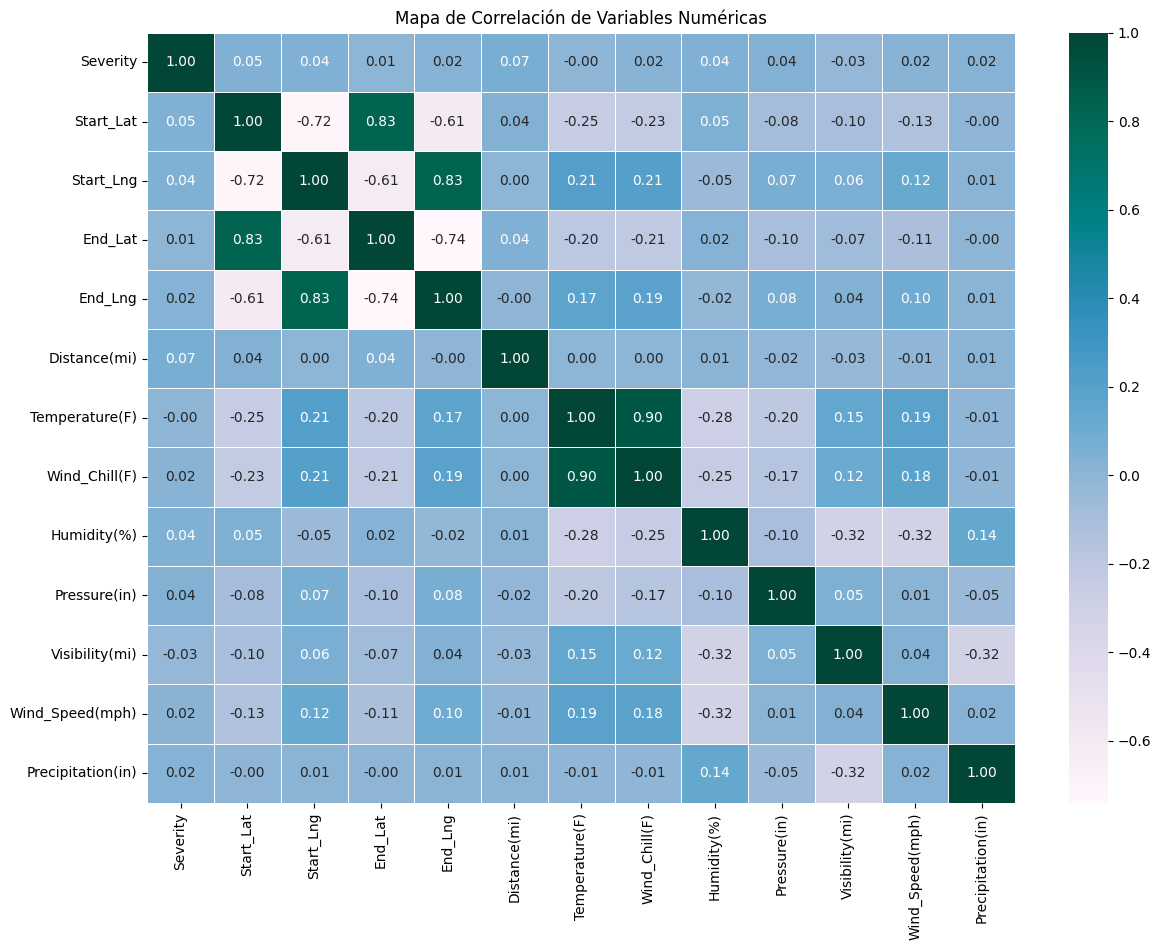

In [ ]:
# Mapa de correlación
corr_matrix = df_label_encoded[number_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='PuBuGn', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()

### 6.2 Análisis de Severidad

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ── Datos ─────────────────────────────────────────────────────────────────────
severity_hour = (traffic_accidents_raw
                 .groupby('Hour')['MUTCD_Severity']
                 .mean().reset_index(name='Severidad_Promedio'))

severity_weather = (traffic_accidents_raw
                    .groupby('Weather_Condition')
                    .agg(
                        Severidad_Promedio=('MUTCD_Severity','mean'),
                        Total_Accidentes=('MUTCD_Severity','count')
                    )
                    .reset_index()
                    .query('Total_Accidentes >= 100')
                    .sort_values('Severidad_Promedio', ascending=False)
                    .head(15))

severity_county = (traffic_accidents_raw
                   .groupby('County')
                   .agg(
                       Severidad_Promedio=('MUTCD_Severity','mean'),
                       Total_Accidentes=('MUTCD_Severity','count')
                   )
                   .reset_index()
                   .query('Total_Accidentes >= 50')
                   .sort_values('Severidad_Promedio', ascending=False)
                   .head(20))

# ── Subplots: 1 fila, 3 columnas ─────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        'Severidad por Hora del Día',
        'Top 15 Condiciones Climáticas',
        'Top 20 Condados'
    ),
    horizontal_spacing=0.12
)

# ── Gráfica 1: Line chart por hora ───────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=severity_hour['Hour'],
        y=severity_hour['Severidad_Promedio'],
        mode='lines+markers',
        line=dict(color='#e63946', width=2),
        marker=dict(size=6),
        name='Por Hora'
    ),
    row=1, col=1
)

# ── Gráfica 2: Bar horizontal por clima ──────────────────────────────────────
fig.add_trace(
    go.Bar(
        x=severity_weather['Severidad_Promedio'],
        y=severity_weather['Weather_Condition'],
        orientation='h',
        text=severity_weather['Severidad_Promedio'].round(2),
        textposition='outside',
        marker=dict(
            color=severity_weather['Severidad_Promedio'],
            colorscale='YlOrRd',
            showscale=False
        ),
        name='Por Clima'
    ),
    row=1, col=2
)

# ── Gráfica 3: Bar vertical por condado ──────────────────────────────────────
fig.add_trace(
    go.Bar(
        x=severity_county['County'],
        y=severity_county['Severidad_Promedio'],
        text=severity_county['Severidad_Promedio'].round(2),
        textposition='outside',
        marker=dict(
            color=severity_county['Severidad_Promedio'],
            colorscale='YlOrRd',
            showscale=False
        ),
        name='Por Condado'
    ),
    row=1, col=3
)

# ── Ejes ──────────────────────────────────────────────────────────────────────
fig.update_xaxes(title_text='Hora',            tickangle=90,
                 row=1, col=1)
fig.update_xaxes(title_text='Severidad Prom.', tickangle=90,
                 title_standoff=15, automargin=True, row=1, col=2)
fig.update_xaxes(title_text='Condado',         tickangle=90,
                 row=1, col=3)

fig.update_yaxes(title_text='Severidad Promedio', row=1, col=1)
fig.update_yaxes(title_text='',                   row=1, col=2)
fig.update_yaxes(title_text='Severidad Promedio', row=1, col=3)

# ── Layout ────────────────────────────────────────────────────────────────────
fig.update_layout(
    height=500,
    width=1800,
    template='seaborn',
    font=dict(size=11),
    title_text='Análisis de Severidad — Florida',
    title_x=0.5,
    showlegend=False
)

fig.show()

# ── Resúmenes en

In [ ]:
# Top 3 condados con más ocurrencias
top3_condados = (traffic_accidents_raw
                 .groupby('County')
                 .agg(
                     Severidad_Promedio=('MUTCD_Severity', 'mean'),
                     Total_Accidentes=('MUTCD_Severity', 'count')
                 )
                 .query('Total_Accidentes >= 50')
                 .sort_values('Severidad_Promedio', ascending=False)
                 .head(3)
                 .index
                 .tolist())
# Nuevo dataset: severidad promedio por hora y condado
severity_hour_county = (traffic_accidents_raw[traffic_accidents_raw['County'].isin(top3_condados)]
                        .groupby(['County', 'Hour'])['MUTCD_Severity']
                        .mean()
                        .reset_index(name='Severidad_Promedio'))


# Paleta de colores, uno por condado
colores = ['#e63946', '#457b9d', '#2a9d8f']

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f'{c} County' for c in top3_condados],
    horizontal_spacing=0.08
)

for i, condado in enumerate(top3_condados):
    df_condado = severity_hour_county[severity_hour_county['County'] == condado]

    fig.add_trace(
        go.Scatter(
            x=df_condado['Hour'],
            y=df_condado['Severidad_Promedio'],
            mode='lines+markers',
            line=dict(color=colores[i], width=2),
            marker=dict(size=6),
            name=condado
        ),
        row=1, col=i + 1
    )

    fig.update_xaxes(title_text='Hora del Día', tickmode='linear', dtick=1,
                     tickangle=0, row=1, col=i + 1)
    fig.update_yaxes(title_text='Severidad Promedio', row=1, col=i + 1)

fig.update_layout(
    height=400, width=1800,
    template='plotly_white',
    font=dict(size=12),
    title_text='Severidad Promedio por Hora — Top 3 Condados',
    title_x=0.5
)

fig.show()

In [ ]:
# Resumen integrado: Ocurrencia + Severidad por condado
resumen_county = (traffic_accidents_raw
                  .groupby('County')
                  .agg(
                      Ocurrencias=('MUTCD_Severity','count'),
                      Severidad_Promedio=('MUTCD_Severity','mean')
                  )
                  .reset_index())

resumen_county['Riesgo_Ocurrencia'] = clasificar_ocurrencia(resumen_county['Ocurrencias'])
resumen_county['Nivel_Severidad']   = pd.cut(
    resumen_county['Severidad_Promedio'],
    bins=[0, 1.5, 2.0, 2.5, 4],
    labels=['Baja','Moderada','Alta','Crítica']
)

fig = px.scatter(resumen_county,
                 x='Ocurrencias', y='Severidad_Promedio',
                 color='Riesgo_Ocurrencia', size='Ocurrencias',
                 hover_name='County',
                 color_discrete_map=color_ocurrencia,
                 template='seaborn',
                 title='Relación Ocurrencia vs Severidad por Condado — Florida<br>'
                       '<sup>Cada punto es un condado. Tamaño = número de accidentes</sup>')
fig.update_layout(height=550, width=1000, font=dict(size=13))
fig.show()

print('=== PERFIL DE RIESGO COMPLETO POR CONDADO (Top 15) ===')
display(resumen_county.sort_values('Ocurrencias', ascending=False)
        .head(15)[['County','Ocurrencias','Riesgo_Ocurrencia',
                   'Severidad_Promedio','Nivel_Severidad']]
        .reset_index(drop=True))

=== PERFIL DE RIESGO COMPLETO POR CONDADO (Top 15) ===


,County,Ocurrencias,Riesgo_Ocurrencia,Severidad_Promedio,Nivel_Severidad
0,Miami-Dade,251601,Crítico,2.11,Alta
1,Orange,124321,Crítico,2.06,Alta
2,Broward,53865,Crítico,1.91,Moderada
3,Hillsborough,52623,Crítico,1.94,Moderada
4,Duval,41726,Crítico,1.87,Moderada
5,Pinellas,41387,Crítico,1.90,Moderada
6,Lee,34554,Crítico,1.92,Moderada
7,Palm Beach,30931,Crítico,1.87,Moderada
8,Manatee,22153,Crítico,1.96,Moderada
9,Sarasota,20675,Crítico,2.01,Alta


---
## 7. Modelado Predictivo

### Setup del modelo

In [ ]:
# ── MODELADO | Setup ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, accuracy_score)

### RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, accuracy_score)

# 1. Dataset con encoding
df = df_label_encoded.copy()

# 2. Agregar Hour si no existe
if 'Hour' not in df.columns:
    df['Hour'] = pd.to_datetime(
        traffic_accidents_scaled['Start_Time'], errors='coerce'
    ).dt.hour

# 3. Seleccionar columnas relevantes
cols = [
    'MUTCD_Severity',
    # Geográficas
    'Start_Lat', 'Start_Lng', 'Street', 'City', 'County',
    # Infraestructura vial
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
    # Climáticas
    'Wind_Chill(F)', 'Temperature(F)', 'Humidity(%)',
    'Visibility(mi)', 'Wind_Speed(mph)',
    'Weather_Condition', 'Precipitation(in)',
    # Temporal
    'Hour'
]
df = df[cols].dropna()

# 4. Codificar Weather_Condition
df = pd.get_dummies(df, columns=['Weather_Condition'], drop_first=True)

# 5. Variable objetivo — 3 categorías
df['Target'] = pd.cut(
    df['MUTCD_Severity'],
    bins=[0, 1, 2, 4],
    labels=['Low', 'Moderate', 'High']
)
df = df.drop(columns=['MUTCD_Severity'])
df = df.dropna(subset=['Target'])

print('Distribución de la variable objetivo:')
print(df['Target'].value_counts())

# 6. X e y sin split aún
X = df.drop('Target', axis=1)
y = df['Target']

Distribución de la variable objetivo:
Target
Moderate    348150
High        262934
Low         154541
Name: count, dtype: int64


### 7.2 Balanceo de Clases

In [ ]:
# Undersampling — igualar todas las clases al mínimo
print('Distribución antes del balanceo:')
print(y.value_counts())

min_class_count = y.value_counts().min()

# 1. Une X e y en un solo DataFrame para poder muestrear juntos
df_balanced = pd.concat([X, y], axis=1)

# 2.  Agrupa por clase (Low/Moderate/High) y toma exactamente
#     min_class_count muestras de CADA grupo → undersampling
df_balanced = (
    df_balanced
    .groupby('Target', group_keys=False, observed=True)
    .apply(lambda x: x.sample(n=min_class_count, random_state=42))
    .reset_index(drop=True)
    # 3. Mezcla aleatoriamente las filas para que no queden
    #    agrupadas por clase al entrenar
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X = df_balanced.drop(columns=['Target'])
y = df_balanced['Target']

print(f'\nDistribución después del balanceo:')
print(y.value_counts())
print(f'\nTotal registros balanceados: {len(df_balanced):,}')

# Split 80/20 DESPUÉS del balanceo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTraining Set: {len(X_train):,} registros')
print(f'Test Set:     {len(X_test):,} registros')

Distribución antes del balanceo:
Target
Moderate    348150
High        262934
Low         154541
Name: count, dtype: int64


/tmp/ipykernel_140/296976251.py:15: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.




Distribución después del balanceo:
Target
Low         154541
Moderate    154541
High        154541
Name: count, dtype: int64

Total registros balanceados: 463,623

Training Set: 370,898 registros
Test Set:     92,725 registros


En la Distribución antes del balanceo, se identifica que la clase minoritaria NO es pequeña — tienes 154k registros reales de "Low", por lo cual se utiliza UNDERSAMPLING vs SMOTE.

SMOTE está diseñado para cuando tienes 100, 500, o pocos miles de muestras en la clase minoritaria y necesitas generar datos sintéticos para compensar.

### 7.3 Random Forest

In [ ]:
print('=' * 55)
print('           RANDOM FOREST CLASSIFIER')
print('=' * 55)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Validación cruzada
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=kf, scoring='accuracy')
print(f'\n Validación Cruzada (5-Fold):')
print(f'   Scores:  {cv_scores_rf.round(4)}')
print(f'   Media:   {cv_scores_rf.mean():.4f}')
print(f'   Std:     {cv_scores_rf.std():.4f}')

# Entrenamiento y evaluación
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)

print(f'\n Evaluación en Test Set:')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))
print(f'ROC AUC:  {roc_auc_score(y_test, y_prob_rf, multi_class="ovr", average="weighted"):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')

           RANDOM FOREST CLASSIFIER

 Validación Cruzada (5-Fold):
   Scores:  [0.5949 0.5961 0.5935 0.5913 0.5958]
   Media:   0.5943
   Std:     0.0018

 Evaluación en Test Set:
Confusion Matrix:
 [[21347  3814  5747]
 [ 3673 19045  8190]
 [ 5578  9624 15707]]

Classification Report:
               precision    recall  f1-score   support

        High       0.70      0.69      0.69     30908
         Low       0.59      0.62      0.60     30908
    Moderate       0.53      0.51      0.52     30909

    accuracy                           0.61     92725
   macro avg       0.60      0.61      0.60     92725
weighted avg       0.60      0.61      0.60     92725

ROC AUC:  0.7956
Accuracy: 0.6050


### 7.4 Extra Trees

In [ ]:
print('=' * 55)
print('           EXTRA TREES CLASSIFIER')
print('=' * 55)

et = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Validación cruzada
cv_scores_et = cross_val_score(et, X_train, y_train, cv=kf, scoring='accuracy')
print(f'\n Validación Cruzada (5-Fold):')
print(f'   Scores:  {cv_scores_et.round(4)}')
print(f'   Media:   {cv_scores_et.mean():.4f}')
print(f'   Std:     {cv_scores_et.std():.4f}')

# Entrenamiento y evaluación
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
y_prob_et  = et.predict_proba(X_test)

print(f'\n Evaluación en Test Set:')
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_et))
print('\nClassification Report:\n', classification_report(y_test, y_pred_et))
print(f'ROC AUC:  {roc_auc_score(y_test, y_prob_et, multi_class="ovr", average="weighted"):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_et):.4f}')

           EXTRA TREES CLASSIFIER

 Validación Cruzada (5-Fold):
   Scores:  [0.5795 0.581  0.5783 0.5759 0.5781]
   Media:   0.5785
   Std:     0.0017

 Evaluación en Test Set:
Confusion Matrix:
 [[20827  4150  5931]
 [ 3881 18462  8565]
 [ 5766  9829 15314]]

Classification Report:
               precision    recall  f1-score   support

        High       0.68      0.67      0.68     30908
         Low       0.57      0.60      0.58     30908
    Moderate       0.51      0.50      0.50     30909

    accuracy                           0.59     92725
   macro avg       0.59      0.59      0.59     92725
weighted avg       0.59      0.59      0.59     92725

ROC AUC:  0.7766
Accuracy: 0.5889


### 7.5 XGBoost Classifier

In [ ]:
### 7.5 XGBoost Classifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

print('=' * 55)
print('           XGBOOST CLASSIFIER')
print('=' * 55)

# XGBoost necesita el target como entero, no string
le_target = LabelEncoder()
y_train_xgb = le_target.fit_transform(y_train)
y_test_xgb  = le_target.transform(y_test)

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',   # rápido para datasets grandes
    eval_metric='mlogloss'
)

# Validación cruzada
cv_scores_xgb = cross_val_score(xgb, X_train, y_train_xgb, cv=kf, scoring='accuracy')
print(f'\n Validación Cruzada (5-Fold):')
print(f'   Scores:  {cv_scores_xgb.round(4)}')
print(f'   Media:   {cv_scores_xgb.mean():.4f}')
print(f'   Std:     {cv_scores_xgb.std():.4f}')

# Entrenamiento y evaluación
xgb.fit(X_train, y_train_xgb)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

print(f'\n Evaluación en Test Set:')
print('Confusion Matrix:\n', confusion_matrix(y_test_xgb, y_pred_xgb))
print('\nClassification Report:\n', classification_report(
    y_test_xgb, y_pred_xgb, target_names=le_target.classes_
))
print(f'ROC AUC:  {roc_auc_score(y_test_xgb, y_prob_xgb, multi_class="ovr", average="weighted"):.4f}')
print(f'Accuracy: {accuracy_score(y_test_xgb, y_pred_xgb):.4f}')

           XGBOOST CLASSIFIER

 Validación Cruzada (5-Fold):
   Scores:  [0.5709 0.5683 0.5679 0.566  0.5692]
   Media:   0.5685
   Std:     0.0016

 Evaluación en Test Set:
Confusion Matrix:
 [[20355  3880  6673]
 [ 4899 17369  8640]
 [ 6363  9344 15202]]

Classification Report:
               precision    recall  f1-score   support

        High       0.64      0.66      0.65     30908
         Low       0.57      0.56      0.56     30908
    Moderate       0.50      0.49      0.49     30909

    accuracy                           0.57     92725
   macro avg       0.57      0.57      0.57     92725
weighted avg       0.57      0.57      0.57     92725

ROC AUC:  0.7654
Accuracy: 0.5708


### 7.6 Comparación de Modelos + Feature Importance

In [ ]:
print('=' * 55)
print('         COMPARACIÓN DE MODELOS')
print('=' * 55)

results_df = pd.DataFrame({
    'Modelo':        ['Random Forest', 'Extra Trees', 'XGBoost'],
    'CV Media':      [cv_scores_rf.mean(), cv_scores_et.mean(), cv_scores_xgb.mean()],
    'CV Std':        [cv_scores_rf.std(),  cv_scores_et.std(),  cv_scores_xgb.std()],
    'Test Accuracy': [accuracy_score(y_test, y_pred_rf),
                      accuracy_score(y_test, y_pred_et),
                      accuracy_score(y_test_xgb, y_pred_xgb)],
    'ROC AUC':       [
        roc_auc_score(y_test, y_prob_rf,  multi_class='ovr', average='weighted'),
        roc_auc_score(y_test, y_prob_et,  multi_class='ovr', average='weighted'),
        roc_auc_score(y_test_xgb, y_prob_xgb, multi_class='ovr', average='weighted')
    ]
}).round(4)

display(results_df)

# Mejor modelo por ROC AUC
best_idx   = results_df['ROC AUC'].idxmax()
best_name  = results_df.loc[best_idx, 'Modelo']
best_model = rf if best_idx == 0 else et
print(f'\n Mejor modelo: {best_name}')

# Feature Importance
feat_importance = (pd.DataFrame({
    'Feature':    X.columns,
    'Importance': best_model.feature_importances_
})
.sort_values('Importance', ascending=False)
.head(15))

fig = px.bar(feat_importance, x='Importance', y='Feature',
             orientation='h',
             color='Importance', color_continuous_scale='PuBuGn',
             template='seaborn',
             title=f'Top 15 Variables más Importantes — {best_name}')
fig.update_layout(height=600, width=1000, font=dict(size=13))
fig.show()

         COMPARACIÓN DE MODELOS


,Modelo,CV Media,CV Std,Test Accuracy,ROC AUC
0,Random Forest,0.59,0.00,0.60,0.80
1,Extra Trees,0.58,0.00,0.59,0.78
2,XGBoost,0.57,0.00,0.57,0.77



 Mejor modelo: Random Forest
